## <b> Classification Project: Churn Prediction</b>

In [1]:
#library importation:

import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import roc_auc_score

### <b>Data Preparation</b>

In [2]:
df = pd.read_csv('Customer-Churn_data.csv')
print("Dataset shape:", df.shape)

Dataset shape: (7043, 21)


In [3]:
#transpose the columns a rows
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [4]:
#data types of the columns
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [6]:
#column normalization and strings column cleaning
df.columns = df.columns.str.lower().str.replace(' ', '_', regex=False)

strings_columns = list(df.dtypes[df.dtypes=='string'].index)

for col in strings_columns:
    df[col] = df[col].str.lower().str.replace(' ', '_', regex=False)

In [7]:
#df.churn = (df.churn == 'yes').astype(int)
df.churn = (df.churn.str.lower() == 'yes').astype(int)

In [8]:
df.head().T

,0,1,2,3,4
customerid,7590-vhveg,5575-gnvde,3668-qpybk,7795-cfocw,9237-hqitu
gender,female,male,male,male,female
seniorcitizen,0,0,0,0,0
partner,yes,no,no,no,no
dependents,no,no,no,no,no
tenure,1,34,2,45,2
phoneservice,no,yes,yes,no,yes
multiplelines,no_phone_service,no,no,no_phone_service,no
internetservice,dsl,dsl,dsl,dsl,fiber_optic
onlinesecurity,no,yes,yes,yes,no


### <b>Setting up the validation framework</b>

In [9]:
#Data splitting & Target Extraction
df_train_full, df_test = train_test_split(df, test_size=0.2, random_state=1)

In [10]:
df_train, df_val = train_test_split(df_train_full, test_size=0.25, random_state=1)

In [11]:
len(df_train_full), len(df_train), len(df_val), len(df_test)

(5634, 4225, 1409, 1409)

In [12]:
df_train_full = df_train_full.reset_index(drop=True)
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [13]:
y_full_train = df_train_full.churn.values
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

In [14]:
print(f"Original dataset size: {len(df)}")
print(f"Training Full set size: {len(df_train_full)} ({len(df_train_full)/len(df)*100:.1f}%)")
print(f"Test set size: {len(df_test)} ({len(df_test)/len(df)*100:.1f}%)")
print(f"Training set size: {len(df_train)} ({len(df_train)/len(df)*100:.1f}%)")
print(f"Validation set size: {len(df_val)} ({len(df_val)/len(df)*100:.1f}%)")

Original dataset size: 7043
Training Full set size: 5634 (80.0%)
Test set size: 1409 (20.0%)
Training set size: 4225 (60.0%)
Validation set size: 1409 (20.0%)


In [15]:
#del df_train_full['churn']
del df_train['churn']
del df_val['churn']
#del df_test['churn']

### <b>Exploratory Data Analysis</b>

In [16]:
df_train_full.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [17]:
df_train_full.churn.value_counts()

churn
0    4113
1    1521
Name: count, dtype: int64

In [18]:
global_mean = df_train_full.churn.mean()
round(global_mean, 3)

np.float64(0.27)

In [19]:
numerical_vars = df.select_dtypes(include=['int64', 'float64'])
categorical_vars = df.select_dtypes(include=['str'])

print("Numerical Variables:")
print(numerical_vars.columns)

print("\nCategorical Variables:")
print(categorical_vars.columns)

Numerical Variables:
Index(['seniorcitizen', 'tenure', 'monthlycharges', 'totalcharges', 'churn'], dtype='str')

Categorical Variables:
Index(['customerid', 'gender', 'partner', 'dependents', 'phoneservice',
       'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup',
       'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies',
       'contract', 'paperlessbilling', 'paymentmethod'],
      dtype='str')


In [20]:
df_train_full.dtypes

customerid              str
gender                  str
seniorcitizen         int64
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod           str
monthlycharges      float64
totalcharges        float64
churn                 int64
dtype: object

In [21]:
df_train_full.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='str')

In [22]:
categorical = ['gender', 'seniorcitizen', 'partner', 'dependents',
              'phoneservice', 'multiplelines', 'internetservice', 
              'onlinesecurity', 'onlinebackup', 'deviceprotection',
              'techsupport', 'streamingtv', 'streamingmovies',
              'contract', 'paperlessbilling', 'paymentmethod']
numerical = ['tenure', 'monthlycharges', 'totalcharges']

In [23]:
df_train_full[categorical].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

### <b>Feature Importance</b>

#### <b>Churn Rate</b>

In [24]:
female_mean = df_train_full[df_train_full.gender=='female'].churn.mean()
print('gender == female: ', round(female_mean, 3))

male_mean = df_train_full[df_train_full.gender == 'male'].churn.mean()
print('gender == male: ', round(male_mean, 3))

gender == female:  0.277
gender == male:  0.263


In [25]:
print("Global avrg churn:", round(global_mean,3))
print("Female avrg churn to Global avrg churn:", round(female_mean / global_mean,3))
print("Male avrg churn to Global avrg churn:", round(male_mean / global_mean,3))

Global avrg churn: 0.27
Female avrg churn to Global avrg churn: 1.025
Male avrg churn to Global avrg churn: 0.975


In [26]:
print(global_mean - female_mean)
print(global_mean - male_mean)

-0.006855983216553063
0.006754520462819769


In [27]:
partner_yes = df_train_full[df_train_full.partner == 'yes'].churn.mean()
print('partner == yes: ', round(partner_yes, 3))

partner_no = df_train_full[df_train_full.partner == 'no'].churn.mean()
print('partner == no: ', round(partner_no, 3))

partner == yes:  0.205
partner == no:  0.33


In [28]:
print("Global avrg churn:", round(global_mean,3))
print("Customers with partners avrg churn to Global avrg churn:", round(partner_yes / global_mean, 3))
print("Customers without partners avrg churn to Global avrg churn:", round(partner_no / global_mean,3))

Global avrg churn: 0.27
Customers with partners avrg churn to Global avrg churn: 0.759
Customers without partners avrg churn to Global avrg churn: 1.222


In [29]:
print(global_mean - partner_yes)
print(global_mean - partner_no)

0.06493474245795922
-0.05984095297455855


In [30]:
#Actual Churn Group
print("Global avrg churn:", round(global_mean,3))
print("Churn rate of customers with partners:", round(global_mean * (partner_yes / global_mean),3))
print("Churn rate of customers without partners:",round(global_mean * (partner_no / global_mean),3))

Global avrg churn: 0.27
Churn rate of customers with partners: 0.205
Churn rate of customers without partners: 0.33


#### <b>Risk Ratio</b>

In [31]:
df_group = df_train_full.groupby(by='gender').churn.agg(['mean'])
df_group['diff'] = df_group['mean'] - global_mean
df_group['risk'] = df_group['mean'] / global_mean
df_group

,mean,diff,risk
gender,,,
female,0.276824,0.006856,1.025396
male,0.263214,-0.006755,0.974980


In [32]:
from IPython.display import display

In [33]:
global_mean = df_train_full.churn.mean()
global_mean

np.float64(0.26996805111821087)

In [34]:
for col in categorical:
    df_group = ( 
        df_train_full
            .groupby(by=col)
            .churn
            .agg(['mean'])
    )
    df_group['diff'] = df_group['mean'] - global_mean
    df_group['risk'] = df_group['mean'] / global_mean
    display(df_group.sort_values('risk', ascending=False))

,mean,diff,risk
gender,,,
female,0.276824,0.006856,1.025396
male,0.263214,-0.006755,0.974980


,mean,diff,risk
seniorcitizen,,,
1,0.413377,0.143409,1.531208
0,0.242270,-0.027698,0.897403


,mean,diff,risk
partner,,,
no,0.329809,0.059841,1.221659
yes,0.205033,-0.064935,0.759472


,mean,diff,risk
dependents,,,
no,0.313760,0.043792,1.162212
yes,0.165666,-0.104302,0.613651


,mean,diff,risk
phoneservice,,,
yes,0.273049,0.003081,1.011412
no,0.241316,-0.028652,0.893870


,mean,diff,risk
multiplelines,,,
yes,0.290742,0.020773,1.076948
no,0.257407,-0.012561,0.953474
no_phone_service,0.241316,-0.028652,0.893870


,mean,diff,risk
internetservice,,,
fiber_optic,0.425171,0.155203,1.574895
dsl,0.192347,-0.077621,0.712482
no,0.077805,-0.192163,0.288201


,mean,diff,risk
onlinesecurity,,,
no,0.420921,0.150953,1.559152
yes,0.153226,-0.116742,0.567570
no_internet_service,0.077805,-0.192163,0.288201


,mean,diff,risk
onlinebackup,,,
no,0.404323,0.134355,1.497672
yes,0.217232,-0.052736,0.804660
no_internet_service,0.077805,-0.192163,0.288201


,mean,diff,risk
deviceprotection,,,
no,0.395875,0.125907,1.466379
yes,0.230412,-0.039556,0.853480
no_internet_service,0.077805,-0.192163,0.288201


,mean,diff,risk
techsupport,,,
no,0.418914,0.148946,1.551717
yes,0.159926,-0.110042,0.592390
no_internet_service,0.077805,-0.192163,0.288201


,mean,diff,risk
streamingtv,,,
no,0.342832,0.072864,1.269897
yes,0.302723,0.032755,1.121328
no_internet_service,0.077805,-0.192163,0.288201


,mean,diff,risk
streamingmovies,,,
no,0.338906,0.068938,1.255358
yes,0.307273,0.037305,1.138182
no_internet_service,0.077805,-0.192163,0.288201


,mean,diff,risk
contract,,,
month-to-month,0.431701,0.161733,1.599082
one_year,0.120573,-0.149395,0.446621
two_year,0.028274,-0.241694,0.104730


,mean,diff,risk
paperlessbilling,,,
yes,0.338151,0.068183,1.252560
no,0.172071,-0.097897,0.637375


,mean,diff,risk
paymentmethod,,,
electronic_check,0.455890,0.185922,1.688682
mailed_check,0.193870,-0.076098,0.718121
bank_transfer_(automatic),0.168171,-0.101797,0.622928
credit_card_(automatic),0.164339,-0.105630,0.608733


#### <b>Mutual Importance</b>

In [35]:
from sklearn.metrics import mutual_info_score

In [36]:
print(mutual_info_score(df_train_full.churn, df_train_full.contract))
print(mutual_info_score(df_train_full.churn, df_train_full.gender))

0.0983203874041556
0.0001174846211139946


In [37]:
def calculate_mi(series):
    return mutual_info_score(series, df_train_full.churn)

df_mi = df_train_full[categorical].apply(calculate_mi)

df_mi = (
    df_mi
        .sort_values(ascending=False)
        .to_frame(name='MI')
   
)

display(df_mi.head())
display(df_mi.tail())

,MI
contract,0.098320
onlinesecurity,0.063085
techsupport,0.061032
internetservice,0.055868
onlinebackup,0.046923


,MI
partner,0.009968
seniorcitizen,0.009410
multiplelines,0.000857
phoneservice,0.000229
gender,0.000117


#### <b>Correlation</b>

In [38]:
#direction
df_train_full[numerical].corrwith(df_train_full.churn).to_frame('correlation')

,correlation
tenure,-0.351885
monthlycharges,0.196805
totalcharges,-0.196353


In [39]:
#absolute impact
df_train_full[numerical].corrwith(df_train_full.churn).abs().to_frame('correlation')

,correlation
tenure,0.351885
monthlycharges,0.196805
totalcharges,0.196353


In [40]:
print(df_train_full[df_train_full.tenure <= 2].churn.mean())
print(df_train_full[df_train_full.tenure > 2].churn.mean())
print(df_train_full[(df_train_full.tenure > 2) & (df_train_full.tenure <= 12)].churn.mean())
print(df_train_full[df_train_full.tenure > 12].churn.mean())

0.5953420669577875
0.22478269658378816
0.3994413407821229
0.17634908339788277


In [41]:
print(df_train_full[df_train_full.monthlycharges <= 20].churn.mean())
print(df_train_full[(df_train_full.monthlycharges > 20) & (df_train_full.monthlycharges <=50)].churn.mean())
print(df_train_full[df_train_full.monthlycharges > 50].churn.mean())

0.08795411089866156
0.18340943683409436
0.32499341585462205


#### <b>One-hot encoding</b>

In [42]:
train_dict = df_train[categorical + numerical].to_dict(orient='records')

In [43]:
train_dict[0]

{'gender': 'female',
 'seniorcitizen': 0,
 'partner': 'yes',
 'dependents': 'yes',
 'phoneservice': 'yes',
 'multiplelines': 'yes',
 'internetservice': 'fiber_optic',
 'onlinesecurity': 'yes',
 'onlinebackup': 'yes',
 'deviceprotection': 'yes',
 'techsupport': 'yes',
 'streamingtv': 'yes',
 'streamingmovies': 'yes',
 'contract': 'two_year',
 'paperlessbilling': 'yes',
 'paymentmethod': 'electronic_check',
 'tenure': 72,
 'monthlycharges': 115.5,
 'totalcharges': 8425.15}

In [44]:
dv = DictVectorizer(sparse=False)
dv.fit(train_dict)

,"dtype dtype: dtype, default=np.float64The type of feature values. Passed to Numpy array/scipy.sparse matrixconstructors as the dtype argument.",<class 'numpy.float64'>
,"separator separator: str, default=""=""Separator string used when constructing new features for one-hotcoding.",'='
,"sparse sparse: bool, default=TrueWhether transform should produce scipy.sparse matrices.",False
,"sort sort: bool, default=TrueWhether ``feature_names_`` and ``vocabulary_`` should besorted when fitting.",True


In [45]:
X_train = dv.transform(train_dict)

In [46]:
X_train.shape

(4225, 45)

In [47]:
dv.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'dependents=no', 'dependents=yes',
       'deviceprotection=no', 'deviceprotection=no_internet_service',
       'deviceprotection=yes', 'gender=female', 'gender=male',
       'internetservice=dsl', 'internetservice=fiber_optic',
       'internetservice=no', 'monthlycharges', 'multiplelines=no',
       'multiplelines=no_phone_service', 'multiplelines=yes',
       'onlinebackup=no', 'onlinebackup=no_internet_service',
       'onlinebackup=yes', 'onlinesecurity=no',
       'onlinesecurity=no_internet_service', 'onlinesecurity=yes',
       'paperlessbilling=no', 'paperlessbilling=yes', 'partner=no',
       'partner=yes', 'paymentmethod=bank_transfer_(automatic)',
       'paymentmethod=credit_card_(automatic)',
       'paymentmethod=electronic_check', 'paymentmethod=mailed_check',
       'phoneservice=no', 'phoneservice=yes', 'seniorcitizen',
       'streamingmovies=no', 'streamingmovies=no_internet_service',

In [48]:
val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [49]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [50]:
z = np.linspace(-7, 7, 51)
z

array([-7.0000000e+00, -6.7200000e+00, -6.4400000e+00, -6.1600000e+00,
       -5.8800000e+00, -5.6000000e+00, -5.3200000e+00, -5.0400000e+00,
       -4.7600000e+00, -4.4800000e+00, -4.2000000e+00, -3.9200000e+00,
       -3.6400000e+00, -3.3600000e+00, -3.0800000e+00, -2.8000000e+00,
       -2.5200000e+00, -2.2400000e+00, -1.9600000e+00, -1.6800000e+00,
       -1.4000000e+00, -1.1200000e+00, -8.4000000e-01, -5.6000000e-01,
       -2.8000000e-01,  8.8817842e-16,  2.8000000e-01,  5.6000000e-01,
        8.4000000e-01,  1.1200000e+00,  1.4000000e+00,  1.6800000e+00,
        1.9600000e+00,  2.2400000e+00,  2.5200000e+00,  2.8000000e+00,
        3.0800000e+00,  3.3600000e+00,  3.6400000e+00,  3.9200000e+00,
        4.2000000e+00,  4.4800000e+00,  4.7600000e+00,  5.0400000e+00,
        5.3200000e+00,  5.6000000e+00,  5.8800000e+00,  6.1600000e+00,
        6.4400000e+00,  6.7200000e+00,  7.0000000e+00])

In [51]:
sigmoid(z)

array([9.11051194e-04, 1.20508423e-03, 1.59386223e-03, 2.10780106e-03,
       2.78699622e-03, 3.68423990e-03, 4.86893124e-03, 6.43210847e-03,
       8.49286285e-03, 1.12064063e-02, 1.47740317e-02, 1.94550846e-02,
       2.55807883e-02, 3.35692233e-02, 4.39398154e-02, 5.73241759e-02,
       7.44679452e-02, 9.62155417e-02, 1.23467048e-01, 1.57095469e-01,
       1.97816111e-01, 2.46011284e-01, 3.01534784e-01, 3.63547460e-01,
       4.30453776e-01, 5.00000000e-01, 5.69546224e-01, 6.36452540e-01,
       6.98465216e-01, 7.53988716e-01, 8.02183889e-01, 8.42904531e-01,
       8.76532952e-01, 9.03784458e-01, 9.25532055e-01, 9.42675824e-01,
       9.56060185e-01, 9.66430777e-01, 9.74419212e-01, 9.80544915e-01,
       9.85225968e-01, 9.88793594e-01, 9.91507137e-01, 9.93567892e-01,
       9.95131069e-01, 9.96315760e-01, 9.97213004e-01, 9.97892199e-01,
       9.98406138e-01, 9.98794916e-01, 9.99088949e-01])

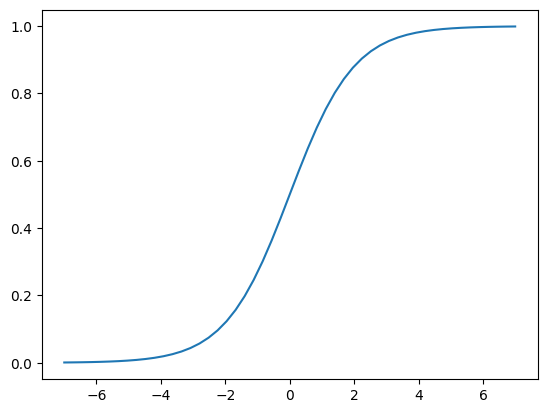

In [52]:
plt.plot(z, sigmoid(z))

### <b>Training Logistic Regression</b>

In [53]:
model = LogisticRegression(solver='liblinear', random_state=1)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [54]:
model.coef_

array([[ 6.17457232e-01, -4.51919371e-02, -6.89764303e-01,
        -2.78977740e-02, -8.96012346e-02,  5.69643271e-02,
        -1.04640000e-01, -6.98233353e-02, -3.84935048e-02,
        -7.90055038e-02, -3.65084051e-01,  3.52225043e-01,
        -1.04640000e-01,  1.67494005e-03, -2.46869273e-01,
         1.33363332e-01, -3.99306757e-03,  6.12475594e-02,
        -1.04640000e-01, -7.41065675e-02,  2.26274923e-01,
        -1.04640000e-01, -2.39133931e-01, -2.41304414e-01,
         1.23805405e-01, -1.21864246e-01,  4.36523712e-03,
        -9.73685399e-02, -4.76807630e-02,  6.89036544e-02,
        -4.13533601e-02,  1.33363332e-01, -2.50862340e-01,
         1.97053079e-01, -9.93224662e-02, -1.04640000e-01,
         8.64634580e-02, -6.11645692e-02, -1.04640000e-01,
         4.83055611e-02,  1.77640402e-01, -1.04640000e-01,
        -1.90499410e-01, -6.81831598e-02,  3.94088603e-04]])

In [55]:
model.coef_[0].round(3)

array([ 0.617, -0.045, -0.69 , -0.028, -0.09 ,  0.057, -0.105, -0.07 ,
       -0.038, -0.079, -0.365,  0.352, -0.105,  0.002, -0.247,  0.133,
       -0.004,  0.061, -0.105, -0.074,  0.226, -0.105, -0.239, -0.241,
        0.124, -0.122,  0.004, -0.097, -0.048,  0.069, -0.041,  0.133,
       -0.251,  0.197, -0.099, -0.105,  0.086, -0.061, -0.105,  0.048,
        0.178, -0.105, -0.19 , -0.068,  0.   ])

In [56]:
model.intercept_

array([-0.11749901])

In [57]:
model.intercept_[0]

np.float64(-0.11749900859134284)

In [58]:
model.predict(X_train)

array([0, 1, 1, ..., 1, 0, 1], shape=(4225,))

In [59]:
model.predict_proba(X_train)

array([[0.92238376, 0.07761624],
       [0.32588825, 0.67411175],
       [0.36657176, 0.63342824],
       ...,
       [0.48925205, 0.51074795],
       [0.97315235, 0.02684765],
       [0.30047106, 0.69952894]], shape=(4225, 2))

#### <b>Apply Model to the Validation Dataset</b>

In [60]:
model.predict_proba(X_val)

array([[0.9928501 , 0.0071499 ],
       [0.79061442, 0.20938558],
       [0.78035856, 0.21964144],
       ...,
       [0.84963644, 0.15036356],
       [0.21732572, 0.78267428],
       [0.18919938, 0.81080062]], shape=(1409, 2))

In [61]:
y_pred = model.predict_proba(X_val)[:,1]
y_pred

array([0.0071499 , 0.20938558, 0.21964144, ..., 0.15036356, 0.78267428,
       0.81080062], shape=(1409,))

In [62]:
# a threshold of 0.5
churn_decision = y_pred > 0.5
churn_decision

array([False, False, False, ..., False,  True,  True], shape=(1409,))

In [63]:
df_val[churn_decision]

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges
3,8433-wxgna,male,0,no,no,2,yes,no,fiber_optic,yes,no,no,no,no,no,month-to-month,yes,electronic_check,75.70,189.20
8,3440-jpscl,female,0,no,no,6,yes,no,fiber_optic,no,no,yes,yes,yes,yes,month-to-month,yes,mailed_check,99.95,547.65
12,7228-omtpn,male,0,no,no,4,yes,no,fiber_optic,no,no,no,no,yes,yes,month-to-month,yes,electronic_check,88.45,370.65
19,6711-fldfb,female,0,no,no,7,yes,yes,fiber_optic,no,no,no,no,no,no,month-to-month,yes,electronic_check,74.90,541.15
24,2612-ranwt,female,0,no,no,12,yes,yes,fiber_optic,no,no,yes,no,yes,yes,month-to-month,yes,bank_transfer_(automatic),100.15,1164.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1397,5976-jcjrh,male,0,yes,no,10,yes,no,fiber_optic,no,no,no,no,no,no,month-to-month,yes,electronic_check,70.30,738.20
1398,2034-cgrhz,male,1,no,no,24,yes,yes,fiber_optic,no,yes,yes,no,yes,yes,month-to-month,yes,credit_card_(automatic),102.95,2496.70
1399,5276-kqwhg,female,1,no,no,2,yes,no,fiber_optic,no,no,no,no,no,no,month-to-month,yes,electronic_check,69.60,131.65
1407,6521-yytyi,male,0,no,yes,1,yes,yes,fiber_optic,no,no,no,no,yes,yes,month-to-month,yes,electronic_check,93.30,93.30


In [64]:
df_val[churn_decision].customerid

3       8433-wxgna
8       3440-jpscl
12      7228-omtpn
19      6711-fldfb
24      2612-ranwt
           ...    
1397    5976-jcjrh
1398    2034-cgrhz
1399    5276-kqwhg
1407    6521-yytyi
1408    3049-solay
Name: customerid, Length: 316, dtype: str

#### <b> Calculate the Model Accuracy </b>

In [65]:
y_val

array([0, 0, 0, ..., 0, 1, 1], shape=(1409,))

In [66]:
churn_decision.astype(int)

array([0, 0, 0, ..., 0, 1, 1], shape=(1409,))

In [67]:
(y_val == churn_decision).mean()

np.float64(0.8055358410220014)

* An accuracy of <b>80.5%</b> on the <b>validation data</b>

In [68]:
df_pred = pd.DataFrame()
df_pred['probability'] = y_pred
df_pred['prediction'] = churn_decision.astype(int)
df_pred['actual'] = y_val
df_pred['correct'] = df_pred.prediction == df_pred.actual
df_pred

,probability,prediction,actual,correct
0,0.007150,0,0,True
1,0.209386,0,0,True
2,0.219641,0,0,True
3,0.569451,1,1,True
4,0.216838,0,0,True
...,...,...,...,...
1404,0.299968,0,0,True
1405,0.040771,0,1,False
1406,0.150364,0,0,True
1407,0.782674,1,1,True


In [69]:
df_pred.correct.mean()

np.float64(0.8055358410220014)

* The model has an 81% model accuracy. 

### <b>Model Interpretation</b>

In [70]:
dv.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'dependents=no', 'dependents=yes',
       'deviceprotection=no', 'deviceprotection=no_internet_service',
       'deviceprotection=yes', 'gender=female', 'gender=male',
       'internetservice=dsl', 'internetservice=fiber_optic',
       'internetservice=no', 'monthlycharges', 'multiplelines=no',
       'multiplelines=no_phone_service', 'multiplelines=yes',
       'onlinebackup=no', 'onlinebackup=no_internet_service',
       'onlinebackup=yes', 'onlinesecurity=no',
       'onlinesecurity=no_internet_service', 'onlinesecurity=yes',
       'paperlessbilling=no', 'paperlessbilling=yes', 'partner=no',
       'partner=yes', 'paymentmethod=bank_transfer_(automatic)',
       'paymentmethod=credit_card_(automatic)',
       'paymentmethod=electronic_check', 'paymentmethod=mailed_check',
       'phoneservice=no', 'phoneservice=yes', 'seniorcitizen',
       'streamingmovies=no', 'streamingmovies=no_internet_service',

In [71]:
model.coef_[0].round(3)

array([ 0.617, -0.045, -0.69 , -0.028, -0.09 ,  0.057, -0.105, -0.07 ,
       -0.038, -0.079, -0.365,  0.352, -0.105,  0.002, -0.247,  0.133,
       -0.004,  0.061, -0.105, -0.074,  0.226, -0.105, -0.239, -0.241,
        0.124, -0.122,  0.004, -0.097, -0.048,  0.069, -0.041,  0.133,
       -0.251,  0.197, -0.099, -0.105,  0.086, -0.061, -0.105,  0.048,
        0.178, -0.105, -0.19 , -0.068,  0.   ])

In [72]:
dict(zip(dv.get_feature_names_out(), model.coef_[0].round(3)))

{'contract=month-to-month': np.float64(0.617),
 'contract=one_year': np.float64(-0.045),
 'contract=two_year': np.float64(-0.69),
 'dependents=no': np.float64(-0.028),
 'dependents=yes': np.float64(-0.09),
 'deviceprotection=no': np.float64(0.057),
 'deviceprotection=no_internet_service': np.float64(-0.105),
 'deviceprotection=yes': np.float64(-0.07),
 'gender=female': np.float64(-0.038),
 'gender=male': np.float64(-0.079),
 'internetservice=dsl': np.float64(-0.365),
 'internetservice=fiber_optic': np.float64(0.352),
 'internetservice=no': np.float64(-0.105),
 'monthlycharges': np.float64(0.002),
 'multiplelines=no': np.float64(-0.247),
 'multiplelines=no_phone_service': np.float64(0.133),
 'multiplelines=yes': np.float64(-0.004),
 'onlinebackup=no': np.float64(0.061),
 'onlinebackup=no_internet_service': np.float64(-0.105),
 'onlinebackup=yes': np.float64(-0.074),
 'onlinesecurity=no': np.float64(0.226),
 'onlinesecurity=no_internet_service': np.float64(-0.105),
 'onlinesecurity=yes':

#### <b>Training a Smaller Model with Fewer Features </b>

In [73]:
small = ['contract', 'tenure', 'monthlycharges']

df_train[small].iloc[:10]

,contract,tenure,monthlycharges
0,two_year,72,115.50
1,month-to-month,10,95.25
2,month-to-month,5,75.55
3,month-to-month,5,80.85
4,two_year,18,20.10
5,month-to-month,4,30.50
6,month-to-month,1,75.10
7,month-to-month,1,70.30
8,two_year,72,19.75
9,month-to-month,6,109.90


In [74]:
df_train[small].iloc[:10].to_dict(orient='records')

[{'contract': 'two_year', 'tenure': 72, 'monthlycharges': 115.5},
 {'contract': 'month-to-month', 'tenure': 10, 'monthlycharges': 95.25},
 {'contract': 'month-to-month', 'tenure': 5, 'monthlycharges': 75.55},
 {'contract': 'month-to-month', 'tenure': 5, 'monthlycharges': 80.85},
 {'contract': 'two_year', 'tenure': 18, 'monthlycharges': 20.1},
 {'contract': 'month-to-month', 'tenure': 4, 'monthlycharges': 30.5},
 {'contract': 'month-to-month', 'tenure': 1, 'monthlycharges': 75.1},
 {'contract': 'month-to-month', 'tenure': 1, 'monthlycharges': 70.3},
 {'contract': 'two_year', 'tenure': 72, 'monthlycharges': 19.75},
 {'contract': 'month-to-month', 'tenure': 6, 'monthlycharges': 109.9}]

In [75]:
dicts_train_small = df_train[small].to_dict(orient='records')
dicts_val_small = df_val[small].to_dict(orient='records')

In [76]:
dv_small = DictVectorizer(sparse=False)
dv_small.fit(dicts_train_small)

,"dtype dtype: dtype, default=np.float64The type of feature values. Passed to Numpy array/scipy.sparse matrixconstructors as the dtype argument.",<class 'numpy.float64'>
,"separator separator: str, default=""=""Separator string used when constructing new features for one-hotcoding.",'='
,"sparse sparse: bool, default=TrueWhether transform should produce scipy.sparse matrices.",False
,"sort sort: bool, default=TrueWhether ``feature_names_`` and ``vocabulary_`` should besorted when fitting.",True


In [77]:
dv_small.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'monthlycharges', 'tenure'], dtype=object)

In [78]:
X_train_small = dv_small.transform(dicts_train_small)
model_small = LogisticRegression(solver='liblinear', random_state=1)
model_small.fit(X_train_small, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [79]:
w0 = model_small.intercept_[0]
w0

np.float64(-1.8342453417126943)

In [80]:
w = model_small.coef_[0]
w.round(3)

array([ 0.347, -0.641, -1.54 ,  0.027, -0.036])

In [81]:
dict(zip(dv_small.get_feature_names_out(), w.round(3)))

{'contract=month-to-month': np.float64(0.347),
 'contract=one_year': np.float64(-0.641),
 'contract=two_year': np.float64(-1.54),
 'monthlycharges': np.float64(0.027),
 'tenure': np.float64(-0.036)}

#### <b>Model Interpretation</b>

In [82]:
sigmoid(-2.47)

np.float64(0.07798823512936635)

In [83]:
sigmoid(-2.47 + 0.97)

np.float64(0.18242552380635632)

In [84]:
sigmoid(-2.47 + 0.97 + 50 * 0.027)

np.float64(0.46257015465625034)

In [85]:
sigmoid(-2.47 + 0.97 + 50 * 0.027 + 5*(-0.036))

np.float64(0.41824062315816374)

In [86]:
-2.47 + 0.97 + 50 * 0.027 + 5*(-0.036)

-0.3300000000000001

In [87]:
sigmoid(_)

np.float64(0.41824062315816374)

* The likelihood of this customer churning is 41.8%

In [88]:
-2.47 + 0.97 + 60*0.027 + 1*(-0.036)

0.08399999999999966

In [89]:
sigmoid(_)

np.float64(0.5209876607065322)

* The likelihood of this customer churning is 52.0%

In [90]:
-2.47 + (-0.949) + 30*0.027 + 24*(-0.036)

-3.473

In [91]:
sigmoid(_)

np.float64(0.030090303318277657)

* The likelihood of this customer churning is 3.0%

### <b> Using the Model </b>

In [92]:
df_train_full

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,5442-pptjy,male,0,yes,yes,12,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.70,258.35,0
1,6261-rcvns,female,0,no,no,42,yes,no,dsl,yes,...,yes,yes,no,yes,one_year,no,credit_card_(automatic),73.90,3160.55,1
2,2176-osjuv,male,0,yes,no,71,yes,yes,dsl,yes,...,no,yes,no,no,two_year,no,bank_transfer_(automatic),65.15,4681.75,0
3,6161-erdgd,male,0,yes,yes,71,yes,yes,dsl,yes,...,yes,yes,yes,yes,one_year,no,electronic_check,85.45,6300.85,0
4,2364-ufrom,male,0,no,no,30,yes,no,dsl,yes,...,no,yes,yes,no,one_year,no,electronic_check,70.40,2044.75,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,0781-lkxbr,male,1,no,no,9,yes,yes,fiber_optic,no,...,yes,no,yes,yes,month-to-month,yes,electronic_check,100.50,918.60,1
5630,3507-gasnp,male,0,no,yes,60,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.95,1189.90,0
5631,8868-wozgu,male,0,no,no,28,yes,yes,fiber_optic,no,...,yes,no,yes,yes,month-to-month,yes,electronic_check,105.70,2979.50,1
5632,1251-krreg,male,0,no,no,2,yes,yes,dsl,no,...,no,no,no,no,month-to-month,yes,mailed_check,54.40,114.10,1


In [93]:
#getting the dictionaries
dicts_full_train = df_train_full[categorical + numerical].to_dict(orient='records')
dicts_full_train[:3]

[{'gender': 'male',
  'seniorcitizen': 0,
  'partner': 'yes',
  'dependents': 'yes',
  'phoneservice': 'yes',
  'multiplelines': 'no',
  'internetservice': 'no',
  'onlinesecurity': 'no_internet_service',
  'onlinebackup': 'no_internet_service',
  'deviceprotection': 'no_internet_service',
  'techsupport': 'no_internet_service',
  'streamingtv': 'no_internet_service',
  'streamingmovies': 'no_internet_service',
  'contract': 'two_year',
  'paperlessbilling': 'no',
  'paymentmethod': 'mailed_check',
  'tenure': 12,
  'monthlycharges': 19.7,
  'totalcharges': 258.35},
 {'gender': 'female',
  'seniorcitizen': 0,
  'partner': 'no',
  'dependents': 'no',
  'phoneservice': 'yes',
  'multiplelines': 'no',
  'internetservice': 'dsl',
  'onlinesecurity': 'yes',
  'onlinebackup': 'yes',
  'deviceprotection': 'yes',
  'techsupport': 'yes',
  'streamingtv': 'no',
  'streamingmovies': 'yes',
  'contract': 'one_year',
  'paperlessbilling': 'no',
  'paymentmethod': 'credit_card_(automatic)',
  'tenur

In [94]:
#creating a DictVectorizer
dv = DictVectorizer(sparse=False)

In [95]:
# from this dictionaries we get the feature matrix
X_full_train = dv.fit_transform(dicts_full_train)

In [96]:
#training the the model on this feature matrix
y_full_train = df_train_full.churn.values
model = LogisticRegression(solver='liblinear')
model.fit(X_full_train, y_full_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [97]:
# on test data
dicts_test = df_test[categorical + numerical].to_dict(orient='records')
X_test = dv.transform(dicts_test)

In [98]:
# on predictions
y_pred = model.predict_proba(X_test)[:, 1]

In [99]:
#computing accuracy
churn_decision = (y_pred >= 0.5)
(churn_decision == y_test).mean()

np.float64(0.8126330731014905)

* An accuracy of <b>81.5%</b> on the <b>test data</b> is slightly more accurate than what we had in the validation data.
* Minor differences in performance are acceptable, but significant differences between training and validation/test data can indeed indicate potential issues with the model, such as overfitting.
* Ensuring that the model’s performance is consistent across different datasets is an important aspect of model evaluation and generalization.

In [100]:
# a customer sample on our test data
customer = dicts_test[10]
customer

{'gender': 'male',
 'seniorcitizen': 1,
 'partner': 'yes',
 'dependents': 'yes',
 'phoneservice': 'yes',
 'multiplelines': 'no',
 'internetservice': 'fiber_optic',
 'onlinesecurity': 'no',
 'onlinebackup': 'yes',
 'deviceprotection': 'no',
 'techsupport': 'no',
 'streamingtv': 'yes',
 'streamingmovies': 'yes',
 'contract': 'month-to-month',
 'paperlessbilling': 'yes',
 'paymentmethod': 'mailed_check',
 'tenure': 32,
 'monthlycharges': 93.95,
 'totalcharges': 2861.45}

In [101]:
# to get feature matrix on the requested customer as a dictionay
X_small = dv.transform([customer])
X_small

array([[1.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00,
        1.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00,
        0.00000e+00, 1.00000e+00, 0.00000e+00, 9.39500e+01, 1.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00,
        1.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00,
        0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        1.00000e+00, 0.00000e+00, 1.00000e+00, 1.00000e+00, 0.00000e+00,
        0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00,
        1.00000e+00, 0.00000e+00, 0.00000e+00, 3.20000e+01, 2.86145e+03]])

In [102]:
X_small.shape
print('One Customer with 45 features:',X_small.shape)

One Customer with 45 features: (1, 45)


In [103]:
model.predict_proba(X_small)[0, 1]

np.float64(0.4952576432974753)

* This customer has a probability of only <b>49%</b> of churning.
* We assume this customer is not going to churn.

In [104]:
# lets check the actual value
y_test[10]

np.int64(0)

* A decision not sending an email to this customer was correct.

In [105]:
#testing another sample of customer
customer = dicts_test[-1]
X_small = dv.transform([customer])
model.predict_proba(X_small)[0,1]

np.float64(0.6434116025674346)

* We see this customer has a probability of about 65% of churning.
* We assume this customer is going to churn.

In [106]:
# Lets check the actual value
y_test[-1]

np.int64(1)

* The prediction is correct.

### <b>Evaluation Metrics for Classification/b>

In [107]:
len(y_val)

1409

In [108]:
(y_val == churn_decision).sum()

np.int64(867)

In [109]:
print(870 / 1409)

0.6174591909155429


In [110]:
(y_val == churn_decision).mean()

np.float64(0.6153300212916962)

In [111]:
thresholds = np.linspace(0, 1, 21)
thresholds

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])

In [112]:
scores = []

for threshold in thresholds:
    churn_decision = (y_pred >=threshold)
    score = (y_val == churn_decision).mean()
    print('%.2f %.3f' % (threshold, score))
    scores.append(score)

0.00 0.274
0.05 0.404
0.10 0.451
0.15 0.483
0.20 0.505
0.25 0.534
0.30 0.537
0.35 0.558
0.40 0.573
0.45 0.594
0.50 0.615
0.55 0.627
0.60 0.652
0.65 0.674
0.70 0.696
0.75 0.711
0.80 0.722
0.85 0.726
0.90 0.726
0.95 0.726
1.00 0.726


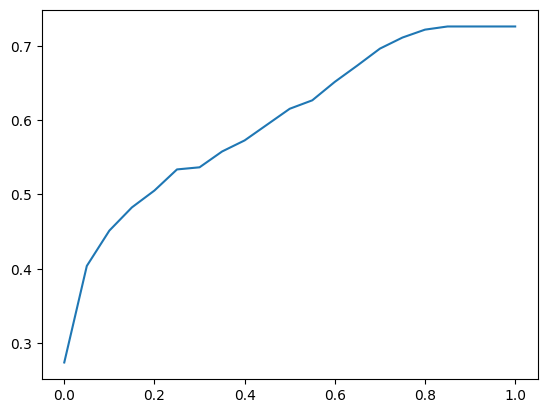

In [113]:
plt.plot(thresholds, scores)

In [114]:
from sklearn.metrics import accuracy_score

In [115]:
thresholds = np.linspace(0, 1, 21)
scores = []

for threshold in thresholds:
    score = accuracy_score(y_val, y_pred >= threshold)
    print('%.2f %.3f' % (threshold, score))
    scores.append(score)

0.00 0.274
0.05 0.404
0.10 0.451
0.15 0.483
0.20 0.505
0.25 0.534
0.30 0.537
0.35 0.558
0.40 0.573
0.45 0.594
0.50 0.615
0.55 0.627
0.60 0.652
0.65 0.674
0.70 0.696
0.75 0.711
0.80 0.722
0.85 0.726
0.90 0.726
0.95 0.726
1.00 0.726


In [116]:
from collections import Counter

In [117]:
Counter(y_pred >= 1.0)

Counter({np.False_: 1409})

In [118]:
Counter(y_val)

Counter({np.int64(0): 1023, np.int64(1): 386})

In [119]:
print(1023/1409)

0.7260468417317246


In [120]:
y_val.mean()

np.float64(0.2739531582682754)

In [121]:
1 - y_val.mean()

np.float64(0.7260468417317246)

In [122]:
#people who are going to churn
actual_positive = (y_val == 1)
#people who are not going to churn
actual_negative = (y_val == 0)

In [123]:
t = 0.5
predict_positive = (y_pred >= t)
predict_negative = (y_pred < t)

In [124]:
predict_positive & actual_positive

array([False, False, False, ..., False, False,  True], shape=(1409,))

In [125]:
tp = (predict_positive & actual_positive).sum()
tp

np.int64(85)

In [126]:
tn = (predict_negative & actual_negative).sum()
tn

np.int64(782)

In [127]:
fp = (predict_positive & actual_negative).sum()
fp

np.int64(241)

In [128]:
fn = (predict_negative & actual_positive).sum()
fn

np.int64(301)

In [129]:
confusion_matrix = np.array([
    [tn, fp],
    [fn, tp]
])

In [130]:
confusion_matrix

array([[782, 241],
       [301,  85]])

In [131]:
(confusion_matrix / confusion_matrix.sum()).round(2)

array([[0.56, 0.17],
       [0.21, 0.06]])

#### <b>Precision & Recall </b>

In [132]:
accuracy = (tp + tn) / (tp + tn + fp + fn)
accuracy

np.float64(0.6153300212916962)

In [133]:
precision = tp / (tp + fp)
precision

np.float64(0.2607361963190184)

In [134]:
# --> promotional email goes to 319 people, but 83 are actually going to churn
tp + fp

np.int64(326)

In [135]:
recall = tp / (tp + fn)
recall

np.float64(0.22020725388601037)

In [136]:
tp + fn

np.int64(386)

#### <b>ROC Curve (Receiver Operating Characteristics)</b>

In [137]:
tpr = tp / (tp + fn)
tpr

np.float64(0.22020725388601037)

In [138]:
recall

np.float64(0.22020725388601037)

In [139]:
fpr = fp / (fp + tn)
fpr

np.float64(0.23558162267839688)

In [140]:
scores = []
thresholds = np.linspace(0, 1, 101)
 
for t in thresholds:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)
 
    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)
 
    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()
 
    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()
 
    scores.append((t, tp, tn, fp, fn))
 
scores

[(np.float64(0.0), np.int64(386), np.int64(0), np.int64(1023), np.int64(0)),
 (np.float64(0.01), np.int64(359), np.int64(105), np.int64(918), np.int64(27)),
 (np.float64(0.02), np.int64(333), np.int64(165), np.int64(858), np.int64(53)),
 (np.float64(0.03), np.int64(322), np.int64(203), np.int64(820), np.int64(64)),
 (np.float64(0.04), np.int64(312), np.int64(239), np.int64(784), np.int64(74)),
 (np.float64(0.05), np.int64(298), np.int64(271), np.int64(752), np.int64(88)),
 (np.float64(0.06), np.int64(290), np.int64(299), np.int64(724), np.int64(96)),
 (np.float64(0.07),
  np.int64(280),
  np.int64(329),
  np.int64(694),
  np.int64(106)),
 (np.float64(0.08),
  np.int64(265),
  np.int64(350),
  np.int64(673),
  np.int64(121)),
 (np.float64(0.09),
  np.int64(256),
  np.int64(375),
  np.int64(648),
  np.int64(130)),
 (np.float64(0.1), np.int64(247), np.int64(389), np.int64(634), np.int64(139)),
 (np.float64(0.11),
  np.int64(241),
  np.int64(412),
  np.int64(611),
  np.int64(145)),
 (np.fl

In [141]:
columns = ['threshold','tp','tn','fp','fn']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores

,threshold,tp,tn,fp,fn
0,0.00,386,0,1023,0
1,0.01,359,105,918,27
2,0.02,333,165,858,53
3,0.03,322,203,820,64
4,0.04,312,239,784,74
...,...,...,...,...,...
96,0.96,0,1023,0,386
97,0.97,0,1023,0,386
98,0.98,0,1023,0,386
99,0.99,0,1023,0,386


In [142]:
df_scores[::10]

,threshold,tp,tn,fp,fn
0,0.0,386,0,1023,0
10,0.1,247,389,634,139
20,0.2,184,528,495,202
30,0.3,137,619,404,249
40,0.4,112,695,328,274
50,0.5,85,782,241,301
60,0.6,52,866,157,334
70,0.7,28,953,70,358
80,0.8,1,1016,7,385
90,0.9,0,1023,0,386


In [143]:
df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)
df_scores[::10]

,threshold,tp,tn,fp,fn,tpr,fpr
0,0.0,386,0,1023,0,1.000000,1.000000
10,0.1,247,389,634,139,0.639896,0.619746
20,0.2,184,528,495,202,0.476684,0.483871
30,0.3,137,619,404,249,0.354922,0.394917
40,0.4,112,695,328,274,0.290155,0.320626
50,0.5,85,782,241,301,0.220207,0.235582
60,0.6,52,866,157,334,0.134715,0.153470
70,0.7,28,953,70,358,0.072539,0.068426
80,0.8,1,1016,7,385,0.002591,0.006843
90,0.9,0,1023,0,386,0.000000,0.000000


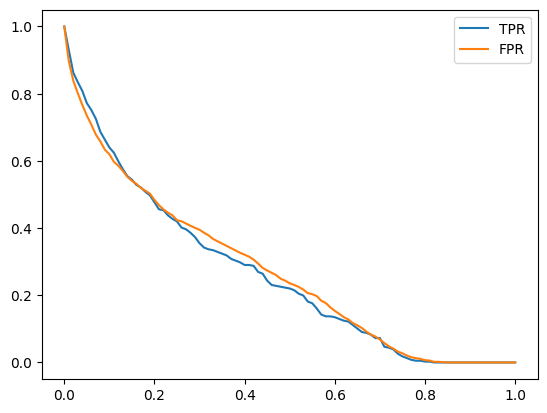

In [144]:
plt.plot(df_scores.threshold, df_scores['tpr'], label='TPR')
plt.plot(df_scores.threshold, df_scores['fpr'], label='FPR')
plt.legend()

#### <b>Random Model</b>

In [145]:
np.random.seed()
y_rand = np.random.uniform(0, 1, size=len(y_val))
y_rand.round(3)

array([0.506, 0.067, 0.829, ..., 0.551, 0.764, 0.215], shape=(1409,))

In [146]:
#Accuracy for our random model
((y_rand >= 0.5) == y_val).mean()

np.float64(0.47835344215755854)

In [147]:
def tpr_fpr_dataframe(y_val, y_pred):
    scores = []
    thresholds = np.linspace(0, 1, 101)

    for t in thresholds:
        actual_positive = (y_val == 1)
        actual_negative = (y_val == 0)

        predict_positive = (y_pred >= t)
        predict_negative = (y_pred < t) 

        tp = (predict_positive & actual_positive).sum()
        tn = (predict_negative & actual_negative).sum()
        fp = (predict_positive & actual_negative).sum()
        fn = (predict_negative & actual_positive).sum()

        scores.append((t, tp, tn, fp, fn))

    columns = ['threshold', 'tp', 'tn', 'fp','fn']
    df_scores = pd.DataFrame(scores, columns=columns)

    df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
    df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)

    return df_scores

In [148]:
df_rand = tpr_fpr_dataframe(y_val, y_rand)
df_rand#[::10]

,threshold,tp,tn,fp,fn,tpr,fpr
0,0.00,386,0,1023,0,1.000000,1.000000
1,0.01,384,10,1013,2,0.994819,0.990225
2,0.02,381,25,998,5,0.987047,0.975562
3,0.03,379,37,986,7,0.981865,0.963832
4,0.04,371,47,976,15,0.961140,0.954057
...,...,...,...,...,...,...,...
96,0.96,13,983,40,373,0.033679,0.039101
97,0.97,8,994,29,378,0.020725,0.028348
98,0.98,4,1004,19,382,0.010363,0.018573
99,0.99,2,1011,12,384,0.005181,0.011730


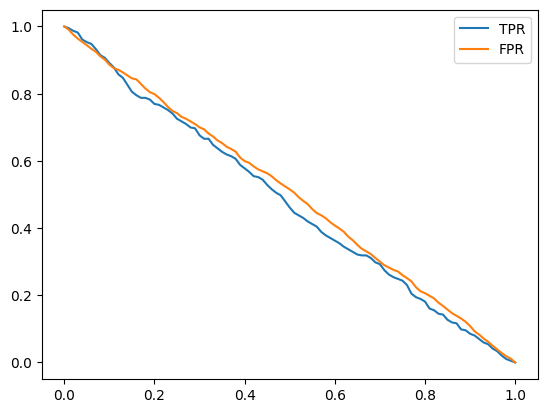

In [149]:
plt.plot(df_rand.threshold, df_rand['tpr'], label='TPR')
plt.plot(df_rand.threshold, df_rand['fpr'], label='FPR')
plt.legend()

#### <b> Ideal Model </b>

In [150]:
num_neg = (y_val == 0).sum()
num_pos = (y_val == 1).sum()
num_neg, num_pos

(np.int64(1023), np.int64(386))

In [151]:
y_ideal = np.repeat([0, 1], [num_neg, num_pos])
y_ideal

array([0, 0, 0, ..., 1, 1, 1], shape=(1409,))

In [152]:
y_ideal_pred = np.linspace(0, 1, len(y_ideal))
y_ideal_pred

array([0.00000000e+00, 7.10227273e-04, 1.42045455e-03, ...,
       9.98579545e-01, 9.99289773e-01, 1.00000000e+00], shape=(1409,))

In [153]:
1 - y_val.mean()

np.float64(0.7260468417317246)

In [154]:
accuracy_ideal = ((y_ideal_pred >= 0.726) == y_ideal).mean()
accuracy_ideal

np.float64(1.0)

In [155]:
df_ideal = tpr_fpr_dataframe(y_ideal, y_ideal_pred)
df_ideal[::10]

,threshold,tp,tn,fp,fn,tpr,fpr
0,0.0,386,0,1023,0,1.000000,1.000000
10,0.1,386,141,882,0,1.000000,0.862170
20,0.2,386,282,741,0,1.000000,0.724340
30,0.3,386,423,600,0,1.000000,0.586510
40,0.4,386,564,459,0,1.000000,0.448680
50,0.5,386,704,319,0,1.000000,0.311828
60,0.6,386,845,178,0,1.000000,0.173998
70,0.7,386,986,37,0,1.000000,0.036168
80,0.8,282,1023,0,104,0.730570,0.000000
90,0.9,141,1023,0,245,0.365285,0.000000


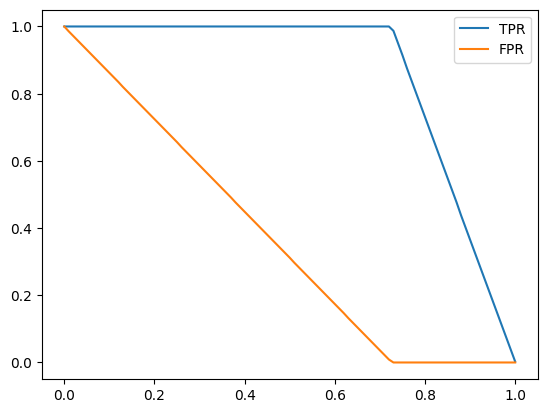

In [156]:
plt.plot(df_ideal.threshold, df_ideal['tpr'], label='TPR')
plt.plot(df_ideal.threshold, df_ideal['fpr'], label='FPR')
plt.legend()

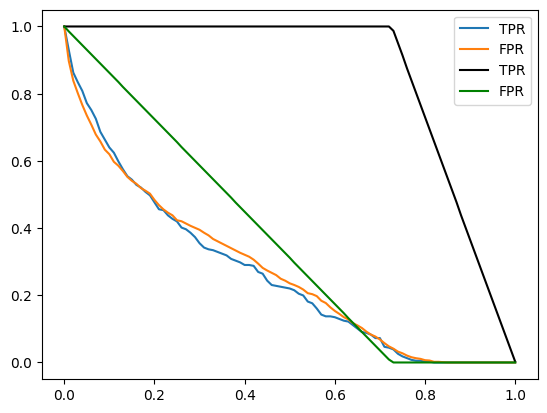

In [157]:
plt.plot(df_scores.threshold, df_scores['tpr'], label='TPR')
plt.plot(df_scores.threshold, df_scores['fpr'], label='FPR')

#plt.plot(df_rand.threshold, df_rand['tpr'], label='TPR')
#plt.plot(df_rand.threshold, df_rand['fpr'], label='FPR')

plt.plot(df_ideal.threshold, df_ideal['tpr'], label='TPR', color='black')
plt.plot(df_ideal.threshold, df_ideal['fpr'], label='FPR', color='green')

plt.legend()

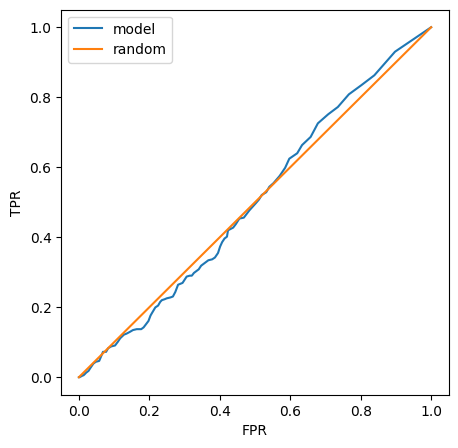

In [158]:
plt.figure(figsize=(5,5))

plt.plot(df_scores.fpr, df_scores.tpr, label='model')
plt.plot([0,1], [0,1], label='random')

#plt.plot(df_rand.fpr, df_rand.tpr, label='random')
#plt.plot(df_ideal.fpr, df_ideal.tpr, label='ideal')

plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()

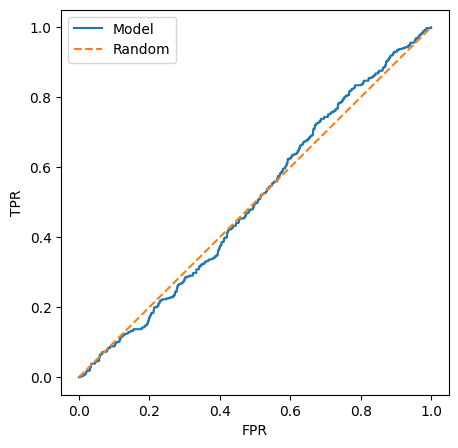

In [159]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_val, y_pred)

plt.figure(figsize=(5,5))

plt.plot(fpr, tpr, label='Model')
plt.plot([0,1], [0,1], label='Random', linestyle='--')

plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()

#### <b> ROC AUC - Area under the ROC curve </b>

In [160]:
from sklearn.metrics import auc
auc(fpr, tpr)

0.502880636551036

In [161]:
auc(df_scores.fpr, df_scores.tpr)

0.5029933295853403

In [162]:
auc(df_ideal.fpr, df_ideal.tpr)

0.9999430203759136

In [163]:
fpr, tpr, thresholds = roc_curve(y_val, y_pred)
auc(fpr, tpr)

0.502880636551036

In [164]:
roc_auc_score(y_val, y_pred)

0.502880636551036

* AUC tells us the probability that a randomly selected positive example has a score that is higher than a randomly selected negative example.

In [165]:
neg = y_pred[y_val == 0]
pos = y_pred[y_val == 1]

In [166]:
import random
pos_ind = random.randint(0, len(pos) -1)
neg_ind = random.randint(0, len(neg) -1)

In [167]:
pos[pos_ind] > neg[neg_ind]

np.True_

In [168]:
n = 100000
success = 0

for i in range(n):
    pos_ind = random.randint(0, len(pos) -1)
    neg_ind = random.randint(0, len(neg) -1)

    if pos[pos_ind] > neg[neg_ind]:
        success +=1

success / n

0.50268

In [169]:
n = 50000

np.random.seed(1)
pos_ind = np.random.randint(0, len(pos), size=n)
neg_ind = np.random.randint(0, len(neg), size=n)
pos[pos_ind] > neg[neg_ind]

array([False,  True, False, ..., False,  True, False], shape=(50000,))

In [170]:
(pos[pos_ind] > neg[neg_ind]).mean()

np.float64(0.50268)

### <b>Cross-Validation: Evaluating the same model on different subsets of data</b>

In [171]:
#K-Fold Cross-Validation
def train(df_train, y_train):
    dicts = df_train[categorical + numerical].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(solver='liblinear')
    model.fit(X_train, y_train)

    return dv, model

In [172]:
dv, model = train(df_train, y_train)

In [173]:
def predict(df, dv, model):
    dicts = df[categorical + numerical].to_dict(orient='records')

    X = dv.fit_transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [174]:
y_pred = predict(df_val, dv, model)
y_pred

array([0.0071499 , 0.20938558, 0.21964144, ..., 0.15036356, 0.78267428,
       0.81080062], shape=(1409,))

In [175]:
from sklearn.model_selection import KFold

In [176]:
kfold = KFold(n_splits = 10, shuffle=True, random_state=1)

In [177]:
kfold.split(df_train_full)

<generator object _BaseKFold.split at 0x1196c29e0>

In [178]:
train_idx, val_idx = next(kfold.split(df_train_full))
len(train_idx), len(val_idx)

(5070, 564)

In [179]:
len(df_train_full)

5634

In [180]:
df_train = df_train_full.iloc[train_idx]
df_val = df_train_full.iloc[val_idx]

In [181]:
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score

kfold = KFold(n_splits=10, shuffle=True, random_state=1)
scores = []

for train_idx, val_idx in kfold.split(df_train_full):
    df_train = df_train_full.iloc[train_idx]
    df_val = df_train_full.iloc[val_idx]

    y_train = df_train.churn.values
    y_val = df_val.churn.values

    dv, model = train(df_train, y_train)
    y_pred = predict(df_val, dv, model)

    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

scores

[0.8493392490816277,
 0.8413366336633662,
 0.8590269587894291,
 0.8330260883877869,
 0.8242400744416873,
 0.840959040959041,
 0.8437154021491371,
 0.8223355471220746,
 0.8445679561286498,
 0.8611811367685119]

In [182]:
!pip3 install tqdm
from tqdm.auto import tqdm

kfold = KFold(n_splits=10, shuffle=True, random_state=1)
scores = []

for train_idx, val_idx in tqdm(kfold.split(df_train_full)):
    df_train = df_train_full.iloc[train_idx]
    df_val = df_train_full.iloc[val_idx]

    y_train = df_train.churn.values
    y_val = df_val.churn.values

    dv, model = train(df_train, y_train)
    y_pred = predict(df_val, dv, model)

    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

scores

/Users/mac/Desktop/ml_projects/classification/customer_churn/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
10it [00:00, 10.84it/s]


[0.8493392490816277,
 0.8413366336633662,
 0.8590269587894291,
 0.8330260883877869,
 0.8242400744416873,
 0.840959040959041,
 0.8437154021491371,
 0.8223355471220746,
 0.8445679561286498,
 0.8611811367685119]

#### <b>Getting the average prediction and the spread within predictions </b>

In [183]:
print('%.3f +- %.3f' % (np.mean(scores), np.std(scores)))

0.842 +- 0.012


#### <b> Parameter Tuning </b>

In [184]:
def train(df_train, y_train, C=1.0):
    dicts = df_train[categorical + numerical].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(C=C,solver='saga', max_iter=3000)
    model.fit(X_train, y_train)

    return dv, model

In [185]:
dv, model = train(df_train, y_train, C=0.001)

In [186]:
from sklearn.model_selection import KFold

kfold = KFold(n_splits=10, shuffle=True, random_state=1)

for C in [0.01, 0.1, 0.5, 1]:

    scores = []

    for train_idx, val_idx in kfold.split(df_train_full):
        df_train = df_train_full.iloc[train_idx]
        df_val = df_train_full.iloc[val_idx]

        y_train = df_train.churn.values
        y_val = df_val.churn.values

        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

        #np.array(scores).round(3)

    print('C=%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))

C=0.01 0.804 +- 0.020
C=0.1 0.804 +- 0.020
C=0.5 0.804 +- 0.020
C=1 0.804 +- 0.020


In [187]:
n_splits = 10

for C in tqdm([0.01, 0.1, 0.5, 1]):
    scores = []

    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

    for train_idx, val_idx in kfold.split(df_train_full):
        df_train = df_train_full.iloc[train_idx]
        df_val = df_train_full.iloc[val_idx]
        
        y_train = df_train.churn.values
        y_val = df_val.churn.values

        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

        print('C=%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))

  0%|                                                                                                                                      | 0/4 [00:00<?, ?it/s]

C=0.01 0.779 +- 0.000
C=0.01 0.793 +- 0.014
C=0.01 0.801 +- 0.016
C=0.01 0.800 +- 0.014
C=0.01 0.795 +- 0.016
C=0.01 0.795 +- 0.014
C=0.01 0.799 +- 0.016
C=0.01 0.797 +- 0.015
C=0.01 0.799 +- 0.016


 25%|███████████████████████████████▌                                                                                              | 1/4 [00:21<01:03, 21.18s/it]

C=0.01 0.804 +- 0.020
C=0.1 0.779 +- 0.000
C=0.1 0.793 +- 0.014
C=0.1 0.801 +- 0.016
C=0.1 0.800 +- 0.014
C=0.1 0.795 +- 0.016
C=0.1 0.795 +- 0.014
C=0.1 0.799 +- 0.016
C=0.1 0.797 +- 0.015
C=0.1 0.799 +- 0.016


 50%|███████████████████████████████████████████████████████████████                                                               | 2/4 [00:41<00:41, 20.86s/it]

C=0.1 0.804 +- 0.020
C=0.5 0.779 +- 0.000
C=0.5 0.793 +- 0.014
C=0.5 0.801 +- 0.016
C=0.5 0.800 +- 0.014
C=0.5 0.795 +- 0.016
C=0.5 0.795 +- 0.014
C=0.5 0.799 +- 0.016
C=0.5 0.797 +- 0.015
C=0.5 0.799 +- 0.016


 75%|██████████████████████████████████████████████████████████████████████████████████████████████▌                               | 3/4 [01:02<00:20, 20.79s/it]

C=0.5 0.804 +- 0.020
C=1 0.779 +- 0.000
C=1 0.793 +- 0.014
C=1 0.801 +- 0.016
C=1 0.800 +- 0.014
C=1 0.795 +- 0.016
C=1 0.795 +- 0.014
C=1 0.799 +- 0.016
C=1 0.797 +- 0.015
C=1 0.799 +- 0.016


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [01:23<00:00, 20.81s/it]

C=1 0.804 +- 0.020


In [188]:
#from sklearn.model_selection import StratifiedKFold

kfold = KFold(n_splits=10, shuffle=True, random_state=1)

for C in [0.01, 0.1, 0.5, 1]:

    scores = []

    for fold, (train_idx, val_idx) in enumerate(
        kfold.split(df_train_full, df_train_full.churn.values)
    ):
        df_train = df_train_full.iloc[train_idx]
        df_val = df_train_full.iloc[val_idx]

        y_train = df_train.churn.values
        y_val = df_val.churn.values

        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

        print(f"C={C}, fold={fold}, auc={auc:.3f}")

    print('C=%s %.3f +- %.3f\n' % (C, np.mean(scores), np.std(scores)))

C=0.01, fold=0, auc=0.779
C=0.01, fold=1, auc=0.807
C=0.01, fold=2, auc=0.817
C=0.01, fold=3, auc=0.797
C=0.01, fold=4, auc=0.776
C=0.01, fold=5, auc=0.797
C=0.01, fold=6, auc=0.819
C=0.01, fold=7, auc=0.784
C=0.01, fold=8, auc=0.816
C=0.01, fold=9, auc=0.845
C=0.01 0.804 +- 0.020

C=0.1, fold=0, auc=0.779
C=0.1, fold=1, auc=0.807
C=0.1, fold=2, auc=0.817
C=0.1, fold=3, auc=0.797
C=0.1, fold=4, auc=0.776
C=0.1, fold=5, auc=0.797
C=0.1, fold=6, auc=0.819
C=0.1, fold=7, auc=0.784
C=0.1, fold=8, auc=0.816
C=0.1, fold=9, auc=0.845
C=0.1 0.804 +- 0.020

C=0.5, fold=0, auc=0.779
C=0.5, fold=1, auc=0.807
C=0.5, fold=2, auc=0.817
C=0.5, fold=3, auc=0.797
C=0.5, fold=4, auc=0.776
C=0.5, fold=5, auc=0.797
C=0.5, fold=6, auc=0.819
C=0.5, fold=7, auc=0.784
C=0.5, fold=8, auc=0.816
C=0.5, fold=9, auc=0.845
C=0.5 0.804 +- 0.020

C=1, fold=0, auc=0.779
C=1, fold=1, auc=0.807
C=1, fold=2, auc=0.817
C=1, fold=3, auc=0.797
C=1, fold=4, auc=0.776
C=1, fold=5, auc=0.797
C=1, fold=6, auc=0.819
C=1, fold=7,

In [189]:
dv, model = train(df_train_full, df_train_full.churn.values, C=1.0)
y_pred = predict(df_test, dv, model)

auc = roc_auc_score(y_test, y_pred)
auc

0.8053330191643103